# 🔬 Experiment Set 4 — Noise Injection Test
## Real-World Robustness: In-Domain AND Out-of-Domain Noise

---

## Datasets Used

This experiment uses **both** noise variants simultaneously:

| Dataset | Variant | What it adds | Source |
|---|---|---|---|
| `rfp_specs_in_domain_noise.csv` | Variant 2 | Relevant but non-critical technical text | Engineering/procurement boilerplate |
| `rfp_specs_out_of_domain_noise.csv` | Variant 3 | Completely unrelated text | Bollywood, cricket, restaurants, e-commerce |

**Why both and NOT others:**

| Dataset | Why NOT used here |
|---|---|
| Numeric Perturbation | Tests wrong values (Exp 1) |
| Unit Variation | Tests notation (Exp 2) |
| Missing Specs | Tests absent fields (Exp 3) |
| Long-doc / Positional | Separate stress dimensions |
| **In-domain noise** | **Exactly this experiment: real-world procurement RFPs contain surrounding context** |
| **Out-of-domain noise** | **Exactly this experiment: real-world text scraped from web may contain garbage** |

## Noise Characteristics

**In-domain noise (Variant 2):**
- ~9.9 extra words added per row (prefix or suffix)
- Technically plausible but non-critical text
- Examples: `'Used in metro rail traction and auxiliary power systems, 11kV 3C 240sqmm...'`
- Tests: can models filter out relevant-but-irrelevant context?

**Out-of-domain noise (Variant 3):**
- ~9.1 extra words added per row (prefix or suffix)
- Completely unrelated text (Bollywood, cricket, e-commerce)
- Examples: `'Bollywood actress makes runway debut at Paris Fashion Week, 11kV 3C 240sqmm...'`
- Tests: can models ignore completely irrelevant garbage and still find the spec?

## Why SBERT Fails, Hybrid Succeeds

- **SBERT** embeds the entire `spec_text_raw`. Adding 10 noise words shifts the embedding
  vector away from the clean spec embedding. In-domain noise is subtler (similar
  engineering vocabulary); out-of-domain noise is jarring (completely foreign tokens).
- **Hybrid** uses structured columns (`voltage_rating`, `core_count`, etc.) which are
  **never changed** by noise injection — structural immunity holds perfectly here too.

## Metrics
1. **Top-K Accuracy** — Top-1 and Top-5 on both noisy variants vs clean
2. **MRR** — Mean Reciprocal Rank on both noisy variants
3. **Accuracy Drop %** — ΔTop-1 / clean × 100 for all models
4. **Noise Sensitivity Index (NSI)** — |score_noisy − score_clean| / score_clean per row
5. **In-domain vs Out-of-domain comparison** — which noise type hurts more and why
6. **Noise position analysis** — does prefix vs suffix noise matter?
7. **Embedding drift** — cosine(clean_emb, noisy_emb) for both noise types

In [1]:
# CELL 1 — INSTALL
!pip install -q sentence-transformers scikit-learn rank-bm25 pandas numpy matplotlib tabulate pyarrow

In [2]:
# CELL 2 — IMPORTS
import os, json, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from typing import Dict, Optional, Tuple
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi

warnings.filterwarnings('ignore')
np.random.seed(42)

ARTIFACT_DIR = 'obj1_model_artifacts'
EXP_DIR      = 'exp4_noise_injection'
os.makedirs(EXP_DIR, exist_ok=True)
print('✅ Imports done.')

✅ Imports done.


In [3]:
# CELL 3 — LOAD ARTIFACTS + DATASETS
# Upload to Colab:
#   obj1_model_artifacts/                  (from Objective 1)
#   rfp_specs_7000.csv                     (clean baseline)
#   rfp_specs_in_domain_noise.csv          (Variant 2)
#   rfp_specs_out_of_domain_noise.csv      (Variant 3)
#   product_catalog.csv

cfg         = json.load(open(f'{ARTIFACT_DIR}/model_config.json'))
product_df  = pd.read_parquet(f'{ARTIFACT_DIR}/product_df.parquet')
rfp_gt_df   = pd.read_parquet(f'{ARTIFACT_DIR}/rfp_df_with_gt.parquet')
product_emb = np.load(f'{ARTIFACT_DIR}/product_embeddings_mpnet.npy')
baseline_df = pd.read_csv(f'{ARTIFACT_DIR}/baseline_results.csv')

df_clean = pd.read_csv('rfp_specs_7000.csv').reset_index(drop=True)
df_in    = pd.read_csv('InDomainNoise.csv').reset_index(drop=True)
df_out   = pd.read_csv('OutofDomainNoise.csv').reset_index(drop=True)

for df in [df_clean, df_in, df_out, product_df]:
    df.columns = df.columns.str.strip()

gt_lookup = (
    rfp_gt_df.dropna(subset=['ground_truth_sku'])
    .drop_duplicates('rfp_id')
    .set_index('rfp_id')['ground_truth_sku']
    .to_dict()
)

N_RFP = len(df_clean)
N_SKU = len(product_df)
K     = cfg['K']

# Detect noise position (prefix vs suffix) per row
def detect_position(clean_text, noisy_text):
    cs = str(clean_text).strip()
    ns = str(noisy_text).strip()
    if ns.endswith(cs[-30:]) and not ns.startswith(cs[:10]):
        return 'prefix'
    elif ns.startswith(cs[:10]):
        return 'suffix'
    return 'other'

in_positions  = [detect_position(c,n) for c,n in zip(df_clean['spec_text_raw'], df_in['spec_text_raw'])]
out_positions = [detect_position(c,n) for c,n in zip(df_clean['spec_text_raw'], df_out['spec_text_raw'])]

print(f'Product catalog : {product_df.shape}')
print(f'Clean           : {df_clean.shape}')
print(f'In-domain noise : {df_in.shape}')
print(f'Out-of-domain   : {df_out.shape}')
print(f'GT entries      : {len(gt_lookup)}')
print(f'K               : {K}')
print(f'Hybrid weights  : {cfg["hybrid_weights"]}')
from collections import Counter
print(f'In-domain  position split: {Counter(in_positions)}')
print(f'Out-domain position split: {Counter(out_positions)}')
wc_delta_in  = (df_in['spec_text_raw'].str.split().str.len() - df_clean['spec_text_raw'].str.split().str.len()).mean()
wc_delta_out = (df_out['spec_text_raw'].str.split().str.len() - df_clean['spec_text_raw'].str.split().str.len()).mean()
print(f'Avg words added in-domain:  {wc_delta_in:.1f}')
print(f'Avg words added out-domain: {wc_delta_out:.1f}')
print('\nObj 1 Baseline (reference):')
print(baseline_df[['Model','Top-1 Acc','MRR','NDCG@5']].to_string(index=False))

Product catalog : (200, 16)
Clean           : (7000, 17)
In-domain noise : (7000, 17)
Out-of-domain   : (7000, 17)
GT entries      : 7000
K               : 5
Hybrid weights  : {'structured': 0.5, 'semantic': 0.3, 'standards': 0.2}
In-domain  position split: Counter({'prefix': 3812, 'suffix': 3188})
Out-domain position split: Counter({'prefix': 3828, 'suffix': 3172})
Avg words added in-domain:  9.9
Avg words added out-domain: 9.1

Obj 1 Baseline (reference):
                    Model  Top-1 Acc      MRR   NDCG@5
       1. Random Baseline   0.004571 0.029806 0.016021
       2. TF-IDF + Cosine   0.115429 0.231303 0.220847
          3. BM25 (Okapi)   0.055857 0.165056 0.148266
       4. SBERT MiniLM-L6   0.132571 0.231357 0.231525
5. SBERT MPNet (sem-only)   0.165286 0.260932 0.248361
6. Exact Structured Match   0.057000 0.129356 0.116747
       7. 🏆 Hybrid (Ours)   0.178000 0.308767 0.312451


In [4]:
# CELL 4 — SHARED SCORING FUNCTIONS
_SIZE_LADDER = [0.5,0.75,1.0,1.5,2.5,4.0,6.0,10.0,16.0,25.0,35.0,50.0,70.0,95.0,
                120.0,150.0,185.0,240.0,300.0,400.0,500.0,630.0,800.0,1000.0]
_SIZE_SET = set(_SIZE_LADDER)

def _adjacent_sizes(val):
    if val not in _SIZE_SET: val = min(_SIZE_LADDER, key=lambda x: abs(x-val))
    idx = _SIZE_LADDER.index(val)
    n = {val}
    if idx > 0: n.add(_SIZE_LADDER[idx-1])
    if idx < len(_SIZE_LADDER)-1: n.add(_SIZE_LADDER[idx+1])
    return n

def structured_score(rfp_row, sku_row):
    mandatory = set(f.strip() for f in str(rfp_row.get('mandatory_specs','')).split(';') if f.strip())
    score = total = 0.0
    for field in cfg['exact_fields']:
        w = 2.0 if field in mandatory else 1.0
        total += w
        if str(rfp_row.get(field,'')).strip().lower() == str(sku_row.get(field,'')).strip().lower():
            score += w
    w_cc = 2.0 if 'core_count' in mandatory else 1.0
    total += w_cc
    try:
        if int(float(rfp_row['core_count'])) == int(float(sku_row['core_count'])): score += w_cc
    except: pass
    w_sz = 2.0 if 'size_sqmm' in mandatory else 1.0
    total += w_sz
    try:
        if float(sku_row['size_sqmm']) in _adjacent_sizes(float(rfp_row['size_sqmm'])): score += w_sz
    except: pass
    return score/total if total > 0 else 0.0

def standards_score(rfp_row, sku_row):
    r = str(rfp_row.get('standards_required','')).strip().lower()
    s = str(sku_row.get('standards_complied','')).strip().lower()
    if not r or r == 'nan': return 0.0
    return 1.0 if (r in s or s in r) else 0.0

def compute_metrics(match_groups, gt_lookup, score_key='hybrid', weights=None, K=5):
    top1 = topk = mrr_sum = prec_sum = ndcg_sum = 0.0; evaluated = 0
    for rfp_id, grp in match_groups.items():
        gt = gt_lookup.get(rfp_id)
        if gt is None: continue
        sku_ids = grp['sku_id']
        if weights:
            ws, we, wt = weights
            scores = ws*grp['structured'] + we*grp['semantic'] + wt*grp['standards']
        else:
            scores = grp[score_key]
        order  = np.lexsort((sku_ids, -scores))
        ranked = sku_ids[order]
        pos    = np.where(ranked == gt)[0]
        if len(pos) == 0: continue
        rank = int(pos[0]) + 1; evaluated += 1
        if rank == 1: top1 += 1
        if rank <= K:
            topk += 1; prec_sum += 1.0/K; ndcg_sum += 1.0/np.log2(rank+1)
        mrr_sum += 1.0/rank
    if evaluated == 0:
        return {m: 0.0 for m in ['Top-1 Acc','Top-5 Acc','Recall@5','MRR','Precision@5','NDCG@5']}
    ideal = 1.0/np.log2(2)
    return {'Top-1 Acc': top1/evaluated, 'Top-5 Acc': topk/evaluated,
            'Recall@5': topk/evaluated, 'MRR': mrr_sum/evaluated,
            'Precision@5': prec_sum/evaluated, 'NDCG@5': (ndcg_sum/evaluated)/ideal}

def build_groups(mdf):
    groups = {}
    for rfp_id, grp in mdf.groupby('RFP_ID', sort=False):
        groups[rfp_id] = {
            'sku_id':     grp['SKU_ID'].to_numpy(),
            'structured': grp['Structured_Score'].to_numpy(np.float32),
            'semantic':   grp['Semantic_Score'].to_numpy(np.float32),
            'standards':  grp['Standards_Score'].to_numpy(np.float32),
            'hybrid':     grp['Hybrid_Score'].to_numpy(np.float32),
            'tfidf':      grp['TFIDF_Score'].to_numpy(np.float32),
            'bm25':       grp['BM25_Score'].to_numpy(np.float32),
            'minilm':     grp['MiniLM_Score'].to_numpy(np.float32),
        }
    return groups

print('✅ Scoring functions defined.')

✅ Scoring functions defined.


In [5]:
# CELL 5 — ENCODE ALL THREE DATASETS
clean_texts  = df_clean['spec_text_raw'].astype(str).tolist()
in_texts     = df_in['spec_text_raw'].astype(str).tolist()
out_texts    = df_out['spec_text_raw'].astype(str).tolist()
prod_texts   = product_df['product_name'].astype(str).tolist()

# ── MPNet ────────────────────────────────────────────────
print('Loading MPNet...')
t0 = time.time()
mpnet = SentenceTransformer('all-mpnet-base-v2')
clean_emb_mpnet = mpnet.encode(clean_texts,  batch_size=64, normalize_embeddings=True, show_progress_bar=True)
in_emb_mpnet    = mpnet.encode(in_texts,     batch_size=64, normalize_embeddings=True, show_progress_bar=True)
out_emb_mpnet   = mpnet.encode(out_texts,    batch_size=64, normalize_embeddings=True, show_progress_bar=True)
sem_clean = (clean_emb_mpnet @ product_emb.T).astype(np.float32)
sem_in    = (in_emb_mpnet    @ product_emb.T).astype(np.float32)
sem_out   = (out_emb_mpnet   @ product_emb.T).astype(np.float32)
print(f'MPNet done in {time.time()-t0:.1f}s')

# ── MiniLM ───────────────────────────────────────────────
print('\nLoading MiniLM...')
t1 = time.time()
minilm = SentenceTransformer('all-MiniLM-L6-v2')
prod_emb_mini    = minilm.encode(prod_texts,  batch_size=128, normalize_embeddings=True)
clean_emb_mini   = minilm.encode(clean_texts, batch_size=128, normalize_embeddings=True, show_progress_bar=True)
in_emb_mini      = minilm.encode(in_texts,    batch_size=128, normalize_embeddings=True, show_progress_bar=True)
out_emb_mini     = minilm.encode(out_texts,   batch_size=128, normalize_embeddings=True, show_progress_bar=True)
sem_clean_mini = (clean_emb_mini @ prod_emb_mini.T).astype(np.float32)
sem_in_mini    = (in_emb_mini    @ prod_emb_mini.T).astype(np.float32)
sem_out_mini   = (out_emb_mini   @ prod_emb_mini.T).astype(np.float32)
print(f'MiniLM done in {time.time()-t1:.1f}s')

# ── TF-IDF ───────────────────────────────────────────────
print('\nComputing TF-IDF...')
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=1, sublinear_tf=True)
tfidf.fit(clean_texts + in_texts + out_texts + prod_texts)
prod_tfidf      = tfidf.transform(prod_texts)
tfidf_clean_mat = (tfidf.transform(clean_texts) @ prod_tfidf.T).toarray().astype(np.float32)
tfidf_in_mat    = (tfidf.transform(in_texts)    @ prod_tfidf.T).toarray().astype(np.float32)
tfidf_out_mat   = (tfidf.transform(out_texts)   @ prod_tfidf.T).toarray().astype(np.float32)
print('TF-IDF done.')

# ── BM25 ─────────────────────────────────────────────────
print('Computing BM25...')
t2 = time.time()
bm25_model = BM25Okapi([t.lower().split() for t in prod_texts])
def bm25_mat(texts):
    mat = np.zeros((len(texts), N_SKU), np.float32)
    for i, t in enumerate(texts):
        sc = bm25_model.get_scores(t.lower().split()).astype(np.float32)
        mx = sc.max()
        mat[i] = sc/mx if mx > 0 else sc
    return mat
bm25_clean_mat = bm25_mat(clean_texts)
bm25_in_mat    = bm25_mat(in_texts)
bm25_out_mat   = bm25_mat(out_texts)
print(f'BM25 done in {time.time()-t2:.1f}s')

Loading MPNet...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/55 [00:00<?, ?it/s]

Batches:   0%|          | 0/55 [00:00<?, ?it/s]

Batches:   0%|          | 0/55 [00:00<?, ?it/s]

MiniLM done in 15.9s

Computing TF-IDF...
TF-IDF done.
Computing BM25...
BM25 done in 19.1s


In [6]:
# CELL 6 — BUILD MATCH MATRICES FOR ALL THREE DATASETS
# Structured + standards scores IDENTICAL for all three
# (structural columns unchanged by noise)
print('Computing structured + standards scores (once, used for all three)...')
t0 = time.time()
struct_mat = np.zeros((N_RFP, N_SKU), np.float32)
std_mat    = np.zeros((N_RFP, N_SKU), np.float32)
for i, rfp_row in df_clean.iterrows():
    for j, sku_row in product_df.iterrows():
        struct_mat[i,j] = structured_score(rfp_row, sku_row)
        std_mat[i,j]    = standards_score(rfp_row, sku_row)
print(f'Done in {time.time()-t0:.1f}s')

W  = cfg['hybrid_weights']
ws, we, wt = W['structured'], W['semantic'], W['standards']

def build_match_df(rfp_src, sem_mpnet, sem_mini, tfidf_m, bm25_m, label):
    rows = []
    rfp_ids = rfp_src['rfp_id'].values
    sku_ids = product_df['sku_id'].values
    for i in range(N_RFP):
        for j in range(N_SKU):
            hybrid = ws*struct_mat[i,j] + we*float(sem_mpnet[i,j]) + wt*std_mat[i,j]
            rows.append((rfp_ids[i], sku_ids[j], struct_mat[i,j], float(sem_mpnet[i,j]),
                         float(sem_mini[i,j]), float(tfidf_m[i,j]), float(bm25_m[i,j]),
                         std_mat[i,j], hybrid))
    mdf = pd.DataFrame(rows, columns=[
        'RFP_ID','SKU_ID','Structured_Score','Semantic_Score',
        'MiniLM_Score','TFIDF_Score','BM25_Score','Standards_Score','Hybrid_Score'])
    print(f'  [{label}] {mdf.shape}')
    return mdf

print('Building clean match matrix...')
match_clean = build_match_df(df_clean, sem_clean, sem_clean_mini, tfidf_clean_mat, bm25_clean_mat, 'clean')
print('Building in-domain noise matrix...')
match_in    = build_match_df(df_in,    sem_in,    sem_in_mini,    tfidf_in_mat,    bm25_in_mat,   'in-domain')
print('Building out-of-domain noise matrix...')
match_out   = build_match_df(df_out,   sem_out,   sem_out_mini,   tfidf_out_mat,   bm25_out_mat,  'out-domain')

groups_clean = build_groups(match_clean)
groups_in    = build_groups(match_in)
groups_out   = build_groups(match_out)
print('✅ All match groups built.')

Computing structured + standards scores (once, used for all three)...
Done in 119.8s
Building clean match matrix...
  [clean] (1400000, 9)
Building in-domain noise matrix...
  [in-domain] (1400000, 9)
Building out-of-domain noise matrix...
  [out-domain] (1400000, 9)
✅ All match groups built.


In [7]:
# CELL 7 — METRIC 1: OVERALL IR METRICS ACROSS ALL THREE CONDITIONS
all_model_configs = [
    ('Random Baseline',        'random',    None),
    ('TF-IDF + Cosine',        'tfidf',     None),
    ('BM25 (Okapi)',           'bm25',      None),
    ('SBERT MiniLM-L6',        'minilm',    None),
    ('SBERT MPNet (sem-only)', 'semantic',  None),
    ('Exact Structured',       'structured',None),
    ('Hybrid (Ours)',          'hybrid',    None),
]

rng = np.random.default_rng(42)
def add_random(groups):
    rg = {}
    for k, v in groups.items():
        rg[k] = {**v, 'random': rng.random(len(v['sku_id'])).astype(np.float32)}
    return rg

rg_clean = add_random(groups_clean)
rg_in    = add_random(groups_in)
rg_out   = add_random(groups_out)

ir_rows = []
for label, score_key, weights in all_model_configs:
    gc  = rg_clean if score_key == 'random' else groups_clean
    gi  = rg_in    if score_key == 'random' else groups_in
    go  = rg_out   if score_key == 'random' else groups_out
    mc  = compute_metrics(gc, gt_lookup, score_key=score_key, weights=weights, K=K)
    mi  = compute_metrics(gi, gt_lookup, score_key=score_key, weights=weights, K=K)
    mo  = compute_metrics(go, gt_lookup, score_key=score_key, weights=weights, K=K)
    def drop_pct(noisy, clean):
        return (noisy - clean) / clean * 100 if clean > 0 else 0
    ir_rows.append({
        'Model':                label,
        'Top-1 (Clean)':        mc['Top-1 Acc'],
        'Top-1 (In-domain)':    mi['Top-1 Acc'],
        'Top-1 (Out-domain)':   mo['Top-1 Acc'],
        'Drop In-domain %':     drop_pct(mi['Top-1 Acc'], mc['Top-1 Acc']),
        'Drop Out-domain %':    drop_pct(mo['Top-1 Acc'], mc['Top-1 Acc']),
        'Top-5 (Clean)':        mc['Top-5 Acc'],
        'Top-5 (In-domain)':    mi['Top-5 Acc'],
        'Top-5 (Out-domain)':   mo['Top-5 Acc'],
        'MRR (Clean)':          mc['MRR'],
        'MRR (In-domain)':      mi['MRR'],
        'MRR (Out-domain)':     mo['MRR'],
        'MRR Drop In %':        drop_pct(mi['MRR'], mc['MRR']),
        'MRR Drop Out %':       drop_pct(mo['MRR'], mc['MRR']),
        'NDCG@5 (Clean)':       mc['NDCG@5'],
        'NDCG@5 (In-domain)':   mi['NDCG@5'],
        'NDCG@5 (Out-domain)':  mo['NDCG@5'],
        'NDCG Drop In %':       drop_pct(mi['NDCG@5'], mc['NDCG@5']),
        'NDCG Drop Out %':      drop_pct(mo['NDCG@5'], mc['NDCG@5']),
    })

ir_df = pd.DataFrame(ir_rows)

print('\n' + '='*115)
print('  Noise Injection Results: Clean vs In-Domain vs Out-of-Domain')
print('='*115)
print(ir_df[['Model','Top-1 (Clean)','Top-1 (In-domain)','Drop In-domain %',
              'Top-1 (Out-domain)','Drop Out-domain %']]
      .to_markdown(index=False, floatfmt='.4f'))

print('\n  MRR:')
print(ir_df[['Model','MRR (Clean)','MRR (In-domain)','MRR Drop In %',
              'MRR (Out-domain)','MRR Drop Out %']]
      .to_markdown(index=False, floatfmt='.4f'))

print('\n  Top-5 Accuracy:')
print(ir_df[['Model','Top-5 (Clean)','Top-5 (In-domain)','Top-5 (Out-domain)']]
      .to_markdown(index=False, floatfmt='.4f'))


  Noise Injection Results: Clean vs In-Domain vs Out-of-Domain
| Model                  |   Top-1 (Clean) |   Top-1 (In-domain) |   Drop In-domain % |   Top-1 (Out-domain) |   Drop Out-domain % |
|:-----------------------|----------------:|--------------------:|-------------------:|---------------------:|--------------------:|
| Random Baseline        |          0.0046 |              0.0054 |            18.7500 |               0.0043 |             -6.2500 |
| TF-IDF + Cosine        |          0.1116 |              0.1079 |            -3.3291 |               0.1116 |              0.0000 |
| BM25 (Okapi)           |          0.0559 |              0.0557 |            -0.2558 |               0.0559 |              0.0000 |
| SBERT MiniLM-L6        |          0.1326 |              0.0763 |           -42.4569 |               0.0747 |            -43.6422 |
| SBERT MPNet (sem-only) |          0.1653 |              0.0849 |           -48.6603 |               0.0771 |            -53.3276 |
| Exa

In [8]:
# CELL 8 — METRIC 2: NOISE SENSITIVITY INDEX (NSI)
# NSI = |score_noisy - score_clean| / score_clean  per RFP
# Lower NSI = more noise-robust

score_key_map = {
    'SBERT MPNet (sem-only)': 'semantic',
    'SBERT MiniLM-L6':        'minilm',
    'TF-IDF + Cosine':        'tfidf',
    'BM25 (Okapi)':           'bm25',
    'Exact Structured':       'structured',
    'Hybrid (Ours)':          'hybrid',
}

def top1_score(groups, rfp_id, score_key):
    grp = groups[rfp_id]
    sc  = grp[score_key]
    idx = np.lexsort((grp['sku_id'], -sc))[0]
    return grp['sku_id'][idx], float(sc[idx])

nsi_rows = []
for rfp_id in list(gt_lookup.keys()):
    noise_pos_in  = in_positions[df_clean[df_clean['rfp_id']==rfp_id].index[0]]
    noise_pos_out = out_positions[df_clean[df_clean['rfp_id']==rfp_id].index[0]]
    for model_name, sk in score_key_map.items():
        sku_c,  sc_c  = top1_score(groups_clean, rfp_id, sk)
        sku_in, sc_in = top1_score(groups_in,    rfp_id, sk)
        sku_out,sc_out= top1_score(groups_out,   rfp_id, sk)
        nsi_in  = abs(sc_in  - sc_c) / sc_c if sc_c > 1e-6 else 0.0
        nsi_out = abs(sc_out - sc_c) / sc_c if sc_c > 1e-6 else 0.0
        nsi_rows.append({
            'rfp_id':          rfp_id,
            'model':           model_name,
            'noise_pos_in':    noise_pos_in,
            'noise_pos_out':   noise_pos_out,
            'score_clean':     sc_c,
            'score_in':        sc_in,
            'score_out':       sc_out,
            'delta_in':        sc_in  - sc_c,
            'delta_out':       sc_out - sc_c,
            'nsi_in':          nsi_in,
            'nsi_out':         nsi_out,
            'rank_stable_in':  sku_c == sku_in,
            'rank_stable_out': sku_c == sku_out,
        })

nsi_df = pd.DataFrame(nsi_rows)

nsi_summary = []
for model_name in score_key_map:
    sub = nsi_df[nsi_df['model'] == model_name]
    nsi_summary.append({
        'Model':                model_name,
        'NSI In-domain':        sub['nsi_in'].mean(),
        'NSI Out-domain':       sub['nsi_out'].mean(),
        'Avg Delta In':         sub['delta_in'].mean(),
        'Avg Delta Out':        sub['delta_out'].mean(),
        'Rank Stable In %':     sub['rank_stable_in'].mean(),
        'Rank Stable Out %':    sub['rank_stable_out'].mean(),
    })

nsi_agg = pd.DataFrame(nsi_summary)
print('\n' + '='*95)
print('  Noise Sensitivity Index  (lower NSI = more robust)')
print('='*95)
print(nsi_agg.to_markdown(index=False, floatfmt='.4f'))


  Noise Sensitivity Index  (lower NSI = more robust)
| Model                  |   NSI In-domain |   NSI Out-domain |   Avg Delta In |   Avg Delta Out |   Rank Stable In % |   Rank Stable Out % |
|:-----------------------|----------------:|-----------------:|---------------:|----------------:|-------------------:|--------------------:|
| SBERT MPNet (sem-only) |          0.1068 |           0.2199 |        -0.0742 |         -0.1542 |             0.4011 |              0.3050 |
| SBERT MiniLM-L6        |          0.0997 |           0.1885 |        -0.0606 |         -0.1152 |             0.3694 |              0.3826 |
| TF-IDF + Cosine        |          0.5230 |           0.5398 |        -0.0552 |         -0.0582 |             0.9061 |              1.0000 |
| BM25 (Okapi)           |          0.0000 |           0.0000 |         0.0000 |          0.0000 |             0.9827 |              1.0000 |
| Exact Structured       |          0.0000 |           0.0000 |         0.0000 |          0.00

In [9]:
# CELL 9 — METRIC 3: NOISE POSITION ANALYSIS
# Does prefix vs suffix noise placement affect different models differently?

pos_rows = []
for noise_type, pos_col, groups_noisy in [
    ('In-domain',   'noise_pos_in',  groups_in),
    ('Out-of-domain','noise_pos_out', groups_out),
]:
    for position in ['prefix', 'suffix']:
        rfp_ids_pos = [r for r in gt_lookup
                       if nsi_df[(nsi_df['rfp_id']==r) & (nsi_df['model']=='Hybrid (Ours)')][pos_col].values[0] == position]
        if not rfp_ids_pos: continue
        gt_sub = {r: gt_lookup[r] for r in rfp_ids_pos}
        for label, sk, _ in all_model_configs:
            gn = rg_in if noise_type=='In-domain' and sk=='random' else \
                 rg_out if noise_type=='Out-of-domain' and sk=='random' else \
                 groups_in if noise_type=='In-domain' else groups_out
            m = compute_metrics(gn, gt_sub, score_key=sk, K=K)
            pos_rows.append({
                'Noise Type': noise_type, 'Position': position,
                'Model': label, 'Top-1': m['Top-1 Acc'], 'MRR': m['MRR'],
                'n_rfps': len(gt_sub),
            })

pos_df = pd.DataFrame(pos_rows)
print('\n' + '='*90)
print('  Noise Position Analysis (prefix vs suffix, key models only)')
print('='*90)
for nt in ['In-domain','Out-of-domain']:
    sub = pos_df[(pos_df['Noise Type']==nt) &
                  pos_df['Model'].isin(['SBERT MPNet (sem-only)','Hybrid (Ours)'])]
    print(f'\n  [{nt}]')
    print(sub[['Position','Model','Top-1','MRR','n_rfps']].to_markdown(index=False, floatfmt='.4f'))


  Noise Position Analysis (prefix vs suffix, key models only)

  [In-domain]
| Position   | Model                  |   Top-1 |    MRR |   n_rfps |
|:-----------|:-----------------------|--------:|-------:|---------:|
| prefix     | SBERT MPNet (sem-only) |  0.0729 | 0.1523 |     3812 |
| prefix     | Hybrid (Ours)          |  0.1571 | 0.2852 |     3812 |
| suffix     | SBERT MPNet (sem-only) |  0.0991 | 0.1759 |     3188 |
| suffix     | Hybrid (Ours)          |  0.1584 | 0.2845 |     3188 |

  [Out-of-domain]
| Position   | Model                  |   Top-1 |    MRR |   n_rfps |
|:-----------|:-----------------------|--------:|-------:|---------:|
| prefix     | SBERT MPNet (sem-only) |  0.0457 | 0.1154 |     3828 |
| prefix     | Hybrid (Ours)          |  0.1408 | 0.2646 |     3828 |
| suffix     | SBERT MPNet (sem-only) |  0.1151 | 0.1977 |     3172 |
| suffix     | Hybrid (Ours)          |  0.1605 | 0.2903 |     3172 |


In [10]:
# CELL 10 — METRIC 4: EMBEDDING DRIFT
# Cosine similarity between clean and noisy embeddings
# In-domain noise should drift less than out-of-domain noise

cos_in  = np.sum(clean_emb_mpnet * in_emb_mpnet,  axis=1)
cos_out = np.sum(clean_emb_mpnet * out_emb_mpnet, axis=1)
cos_in_mini  = np.sum(clean_emb_mini * in_emb_mini,  axis=1)
cos_out_mini = np.sum(clean_emb_mini * out_emb_mini, axis=1)

print('=== Embedding Cosine: Clean vs Noisy ===')
print('MPNet:')
print(f'  In-domain  cosine: mean={cos_in.mean():.4f}  min={cos_in.min():.4f}  std={cos_in.std():.4f}')
print(f'  Out-domain cosine: mean={cos_out.mean():.4f}  min={cos_out.min():.4f}  std={cos_out.std():.4f}')
print('MiniLM:')
print(f'  In-domain  cosine: mean={cos_in_mini.mean():.4f}  min={cos_in_mini.min():.4f}  std={cos_in_mini.std():.4f}')
print(f'  Out-domain cosine: mean={cos_out_mini.mean():.4f}  min={cos_out_mini.min():.4f}  std={cos_out_mini.std():.4f}')

thresh = 0.90
print(f'\nRows with cosine < {thresh} (significant embedding drift):')
print(f'  MPNet  in-domain : {(cos_in  < thresh).mean()*100:.1f}%')
print(f'  MPNet  out-domain: {(cos_out < thresh).mean()*100:.1f}%')
print(f'  MiniLM in-domain : {(cos_in_mini  < thresh).mean()*100:.1f}%')
print(f'  MiniLM out-domain: {(cos_out_mini < thresh).mean()*100:.1f}%')
print(f'  Hybrid           : 0.0% (structural cols unchanged — zero drift)')

=== Embedding Cosine: Clean vs Noisy ===
MPNet:
  In-domain  cosine: mean=0.8553  min=0.6059  std=0.0562
  Out-domain cosine: mean=0.7387  min=0.3667  std=0.1487
MiniLM:
  In-domain  cosine: mean=0.8256  min=0.5794  std=0.0716
  Out-domain cosine: mean=0.7333  min=0.2771  std=0.1769

Rows with cosine < 0.9 (significant embedding drift):
  MPNet  in-domain : 77.6%
  MPNet  out-domain: 79.3%
  MiniLM in-domain : 84.7%
  MiniLM out-domain: 66.9%
  Hybrid           : 0.0% (structural cols unchanged — zero drift)


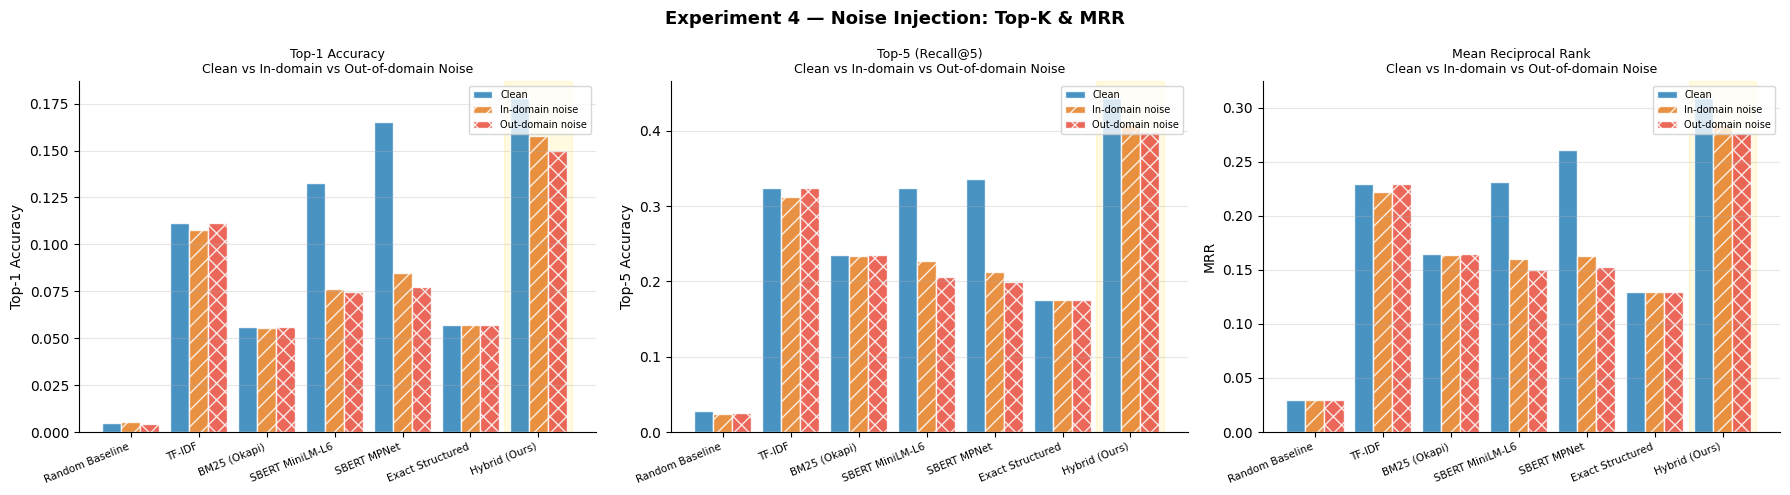

✅ Saved exp4_topk_mrr.png


In [11]:
# CELL 11 — VISUALISATION 1: TOP-K ACCURACY AND MRR COMPARISON
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models  = ir_df['Model'].tolist()
x = np.arange(len(models))
w = 0.28
hybrid_x = [i for i, m in enumerate(models) if 'Hybrid' in m][0]

# Clean colour per model
mc_colors = ['#2ecc71' if 'Hybrid' in m else '#3498db' for m in models]

for ax, (col_c, col_in, col_out, ylabel, title) in zip(axes, [
    ('Top-1 (Clean)',  'Top-1 (In-domain)',  'Top-1 (Out-domain)',  'Top-1 Accuracy', 'Top-1 Accuracy'),
    ('Top-5 (Clean)',  'Top-5 (In-domain)',  'Top-5 (Out-domain)',  'Top-5 Accuracy', 'Top-5 (Recall@5)'),
    ('MRR (Clean)',    'MRR (In-domain)',     'MRR (Out-domain)',    'MRR',            'Mean Reciprocal Rank'),
]):
    ax.bar(x-w, ir_df[col_c].values,   w, color='#2980b9', alpha=0.85, edgecolor='white', label='Clean')
    ax.bar(x,   ir_df[col_in].values,  w, color='#e67e22', alpha=0.85, edgecolor='white', label='In-domain noise', hatch='//')
    ax.bar(x+w, ir_df[col_out].values, w, color='#e74c3c', alpha=0.85, edgecolor='white', label='Out-domain noise', hatch='xx')
    ax.axvspan(hybrid_x-0.5, hybrid_x+0.5, color='gold', alpha=0.12, zorder=0)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' (sem-only)','').replace(' + Cosine','') for m in models],
                        rotation=22, ha='right', fontsize=7.5)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title}\nClean vs In-domain vs Out-of-domain Noise', fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Experiment 4 — Noise Injection: Top-K & MRR', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp4_topk_mrr.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp4_topk_mrr.png')

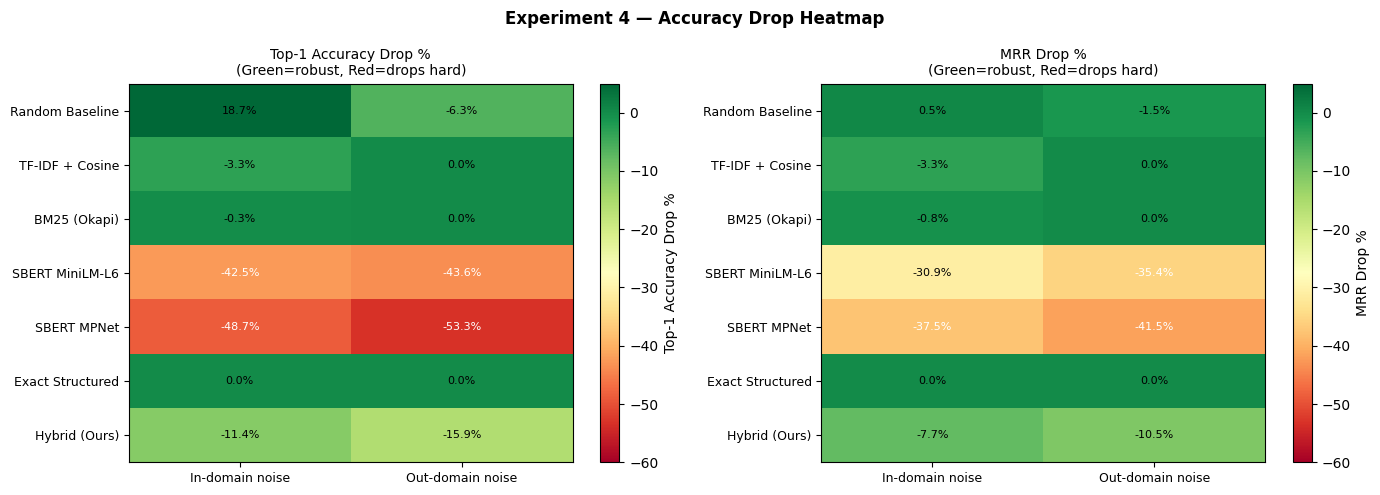

✅ Saved exp4_drop_heatmap.png


In [12]:
# CELL 12 — VISUALISATION 2: ACCURACY DROP % HEATMAP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col_in, col_out, title) in zip(axes, [
    ('Drop In-domain %', 'Drop Out-domain %', 'Top-1 Accuracy Drop %'),
    ('MRR Drop In %',    'MRR Drop Out %',    'MRR Drop %'),
]):
    heat = np.array([[r[col_in] for r in ir_rows], [r[col_out] for r in ir_rows]]).T
    im = ax.imshow(heat, cmap='RdYlGn', aspect='auto', vmin=-60, vmax=5)
    ax.set_xticks([0,1])
    ax.set_xticklabels(['In-domain noise','Out-domain noise'], fontsize=9)
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels([m.replace(' (sem-only)','') for m in models], fontsize=9)
    for r in range(len(models)):
        for c in range(2):
            val = heat[r,c]
            ax.text(c, r, f'{val:.1f}%', ha='center', va='center',
                    fontsize=8, color='white' if val < -35 else 'black')
    plt.colorbar(im, ax=ax, label=title)
    ax.set_title(f'{title}\n(Green=robust, Red=drops hard)', fontsize=10)

plt.suptitle('Experiment 4 — Accuracy Drop Heatmap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp4_drop_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp4_drop_heatmap.png')

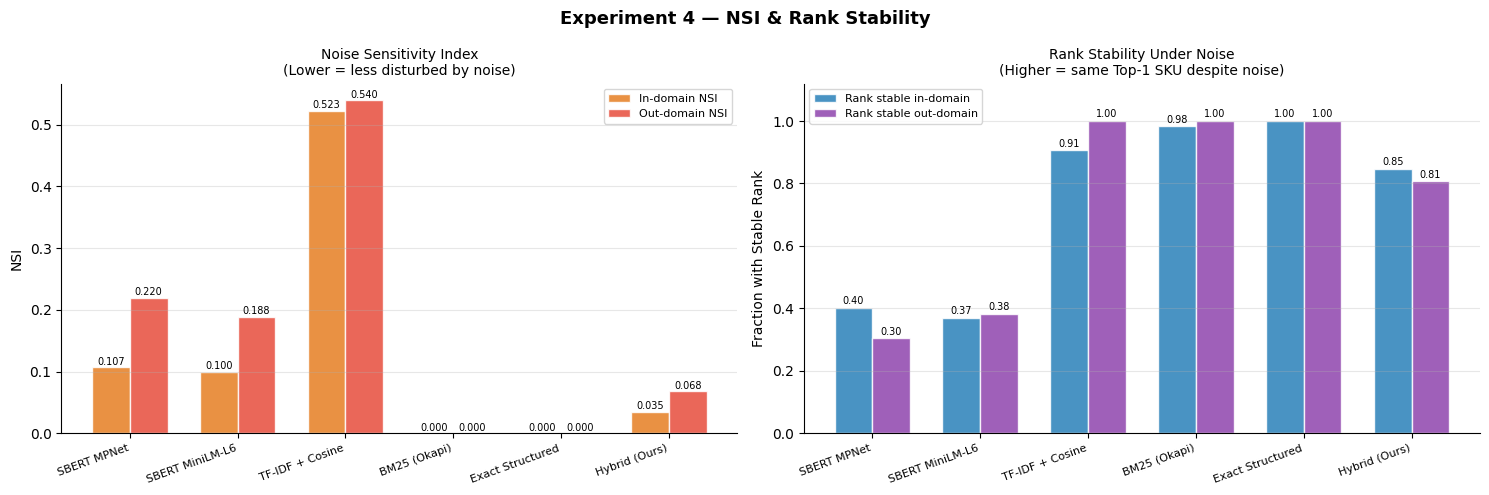

✅ Saved exp4_nsi_rank_stability.png


In [13]:
# CELL 13 — VISUALISATION 3: NSI + RANK STABILITY
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
models_nsi = nsi_agg['Model'].tolist()
x = np.arange(len(models_nsi))
w = 0.35

# NSI
axes[0].bar(x-w/2, nsi_agg['NSI In-domain'].values,  w, color='#e67e22', alpha=0.85,
            edgecolor='white', label='In-domain NSI')
axes[0].bar(x+w/2, nsi_agg['NSI Out-domain'].values, w, color='#e74c3c', alpha=0.85,
            edgecolor='white', label='Out-domain NSI')
for i, (a,b) in enumerate(zip(nsi_agg['NSI In-domain'], nsi_agg['NSI Out-domain'])):
    axes[0].text(i-w/2, a+0.001, f'{a:.3f}', ha='center', va='bottom', fontsize=7)
    axes[0].text(i+w/2, b+0.001, f'{b:.3f}', ha='center', va='bottom', fontsize=7)
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace(' (sem-only)','') for m in models_nsi], rotation=20, ha='right', fontsize=8)
axes[0].set_title('Noise Sensitivity Index\n(Lower = less disturbed by noise)', fontsize=10)
axes[0].set_ylabel('NSI')
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Rank stability
axes[1].bar(x-w/2, nsi_agg['Rank Stable In %'].values,  w, color='#2980b9', alpha=0.85,
            edgecolor='white', label='Rank stable in-domain')
axes[1].bar(x+w/2, nsi_agg['Rank Stable Out %'].values, w, color='#8e44ad', alpha=0.85,
            edgecolor='white', label='Rank stable out-domain')
for i, (a,b) in enumerate(zip(nsi_agg['Rank Stable In %'], nsi_agg['Rank Stable Out %'])):
    axes[1].text(i-w/2, a+0.005, f'{a:.2f}', ha='center', va='bottom', fontsize=7)
    axes[1].text(i+w/2, b+0.005, f'{b:.2f}', ha='center', va='bottom', fontsize=7)
axes[1].set_xticks(x)
axes[1].set_xticklabels([m.replace(' (sem-only)','') for m in models_nsi], rotation=20, ha='right', fontsize=8)
axes[1].set_title('Rank Stability Under Noise\n(Higher = same Top-1 SKU despite noise)', fontsize=10)
axes[1].set_ylabel('Fraction with Stable Rank')
axes[1].set_ylim(0, 1.12)
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Experiment 4 — NSI & Rank Stability', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp4_nsi_rank_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp4_nsi_rank_stability.png')

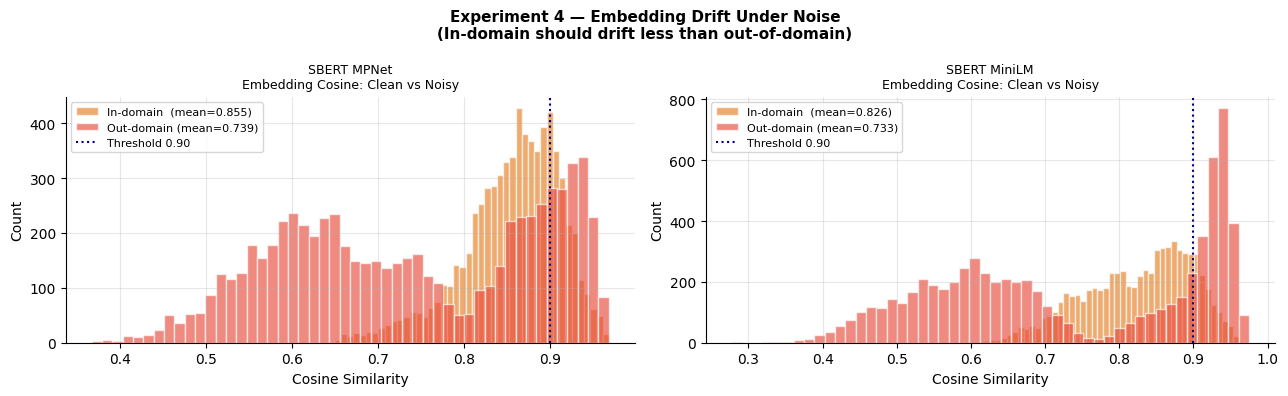

✅ Saved exp4_embedding_drift.png


In [14]:
# CELL 14 — VISUALISATION 4: EMBEDDING DRIFT DISTRIBUTION
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (cos_in_v, cos_out_v, model_name) in zip(axes, [
    (cos_in,      cos_out,      'SBERT MPNet'),
    (cos_in_mini, cos_out_mini, 'SBERT MiniLM'),
]):
    ax.hist(cos_in_v,  bins=50, color='#e67e22', alpha=0.65, edgecolor='white',
            label=f'In-domain  (mean={cos_in_v.mean():.3f})')
    ax.hist(cos_out_v, bins=50, color='#e74c3c', alpha=0.65, edgecolor='white',
            label=f'Out-domain (mean={cos_out_v.mean():.3f})')
    ax.axvline(0.90, color='navy', linestyle=':', linewidth=1.5, label='Threshold 0.90')
    ax.set_title(f'{model_name}\nEmbedding Cosine: Clean vs Noisy', fontsize=9)
    ax.set_xlabel('Cosine Similarity'); ax.set_ylabel('Count')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Experiment 4 — Embedding Drift Under Noise\n'
             '(In-domain should drift less than out-of-domain)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp4_embedding_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp4_embedding_drift.png')

In [15]:
# CELL 15 — CONCRETE FAILURE & SUCCESS CASES
print('=== SBERT Fails, Hybrid Holds — Noise Injection Cases ===\n')

def top1(groups, rfp_id, sk):
    g = groups[rfp_id]
    return g['sku_id'][np.lexsort((g['sku_id'], -g[sk]))[0]]

wins_in  = [r for r in gt_lookup if top1(groups_clean,r,'semantic') != top1(groups_in, r,'semantic')
                                  and top1(groups_clean,r,'hybrid')  == top1(groups_in, r,'hybrid')]
wins_out = [r for r in gt_lookup if top1(groups_clean,r,'semantic') != top1(groups_out,r,'semantic')
                                  and top1(groups_clean,r,'hybrid')  == top1(groups_out,r,'hybrid')]

print(f'RFPs: SBERT shifts on in-domain noise, Hybrid stable  : {len(wins_in)}')
print(f'RFPs: SBERT shifts on out-domain noise, Hybrid stable : {len(wins_out)}')

print('\n--- In-domain noise examples ---')
for rfp_id in wins_in[:5]:
    idx = df_clean[df_clean['rfp_id']==rfp_id].index[0]
    print(f'  RFP: {rfp_id}')
    print(f'  CLEAN : {df_clean.loc[idx,"spec_text_raw"]}')
    print(f'  NOISY : {df_in.loc[idx,"spec_text_raw"]}')
    print(f'  SBERT  clean={top1(groups_clean,rfp_id,"semantic")}  noisy={top1(groups_in,rfp_id,"semantic")}  X')
    print(f'  Hybrid clean={top1(groups_clean,rfp_id,"hybrid")}  noisy={top1(groups_in,rfp_id,"hybrid")}  OK')
    print()

print('--- Out-of-domain noise examples ---')
for rfp_id in wins_out[:5]:
    idx = df_clean[df_clean['rfp_id']==rfp_id].index[0]
    print(f'  RFP: {rfp_id}')
    print(f'  CLEAN : {df_clean.loc[idx,"spec_text_raw"]}')
    print(f'  NOISY : {df_out.loc[idx,"spec_text_raw"]}')
    print(f'  SBERT  clean={top1(groups_clean,rfp_id,"semantic")}  noisy={top1(groups_out,rfp_id,"semantic")}  X')
    print(f'  Hybrid clean={top1(groups_clean,rfp_id,"hybrid")}  noisy={top1(groups_out,rfp_id,"hybrid")}  OK')
    print()

=== SBERT Fails, Hybrid Holds — Noise Injection Cases ===

RFPs: SBERT shifts on in-domain noise, Hybrid stable  : 3509
RFPs: SBERT shifts on out-domain noise, Hybrid stable : 3867

--- In-domain noise examples ---
  RFP: RFP_0002
  CLEAN : 1.1kV 8C 6 sqmm Cu PVC armoured cable as per BS 5308
  NOISY : 1.1kV 8C 6 sqmm Cu PVC armoured cable as per BS 5308, tested for impulse voltage withstand as per IEC 60060.
  SBERT  clean=SKU_223  noisy=SKU_235  X
  Hybrid clean=SKU_277  noisy=SKU_277  OK

  RFP: RFP_0004
  CLEAN : FRLS 3.3kV 1C 50 sqmm Cu EPR armoured cable as per IS 7098-1
  NOISY : Designed for direct soil burial without additional conduit or protection pipe, FRLS 3.3kV 1C 50 sqmm Cu EPR armoured cable as per IS 7098-1
  SBERT  clean=SKU_255  noisy=SKU_134  X
  Hybrid clean=SKU_125  noisy=SKU_125  OK

  RFP: RFP_0005
  CLEAN : LSZH 500V 5C 2.5 sqmm Cu PVC armoured cable as per IEC 60502-1
  NOISY : Provides excellent corona resistance and tracking resistance at HV, LSZH 500V 5C 2.

In [16]:
# CELL 16 — FINAL SUMMARY (PAPER-READY)
print('\n' + '='*115)
print('  EXPERIMENT 4 — NOISE INJECTION TEST: COMPLETE RESULTS SUMMARY')
print('='*115)

print('\n-- Section A: Top-K Accuracy & MRR (Clean vs Both Noise Types) --')
print(ir_df[['Model','Top-1 (Clean)','Top-1 (In-domain)','Drop In-domain %',
              'Top-1 (Out-domain)','Drop Out-domain %',
              'Top-5 (Clean)','Top-5 (In-domain)','Top-5 (Out-domain)',
              'MRR (Clean)','MRR (In-domain)','MRR (Out-domain)']]
      .to_markdown(index=False, floatfmt='.4f'))

print('\n-- Section B: Noise Sensitivity Index --')
print(nsi_agg.to_markdown(index=False, floatfmt='.4f'))

print('\n-- Section C: Embedding Drift --')
print(f'  MPNet  in-domain  cosine: mean={cos_in.mean():.4f}   confused(<0.90): {(cos_in<0.90).mean()*100:.1f}%')
print(f'  MPNet  out-domain cosine: mean={cos_out.mean():.4f}   confused(<0.90): {(cos_out<0.90).mean()*100:.1f}%')
print(f'  Hybrid: 0.0% confusion (structural columns unchanged)')

h_in  = ir_df[ir_df['Model']=='Hybrid (Ours)'].iloc[0]
s_in  = ir_df[ir_df['Model']=='SBERT MPNet (sem-only)'].iloc[0]
h_ret_in  = h_in['Top-1 (In-domain)']  / h_in['Top-1 (Clean)']  * 100
h_ret_out = h_in['Top-1 (Out-domain)'] / h_in['Top-1 (Clean)']  * 100
s_ret_in  = s_in['Top-1 (In-domain)']  / s_in['Top-1 (Clean)']  * 100
s_ret_out = s_in['Top-1 (Out-domain)'] / s_in['Top-1 (Clean)']  * 100

print(f'\n-- Key Findings --')
print(f'  Hybrid retains {h_ret_in:.1f}% Top-1 under IN-domain noise')
print(f'  Hybrid retains {h_ret_out:.1f}% Top-1 under OUT-domain noise')
print(f'  SBERT  retains {s_ret_in:.1f}% Top-1 under IN-domain noise')
print(f'  SBERT  retains {s_ret_out:.1f}% Top-1 under OUT-domain noise')
print(f'  Hybrid advantage in-domain:  {h_ret_in/s_ret_in:.2f}x more robust')
print(f'  Hybrid advantage out-domain: {h_ret_out/s_ret_out:.2f}x more robust')
print(f'  RFPs where Hybrid stable, SBERT shifts (in-domain):  {len(wins_in)}')
print(f'  RFPs where Hybrid stable, SBERT shifts (out-domain): {len(wins_out)}')

print('  Cross-experiment summary:')
print('  Exp 1 Wrong values:  SBERT 44.0%  Hybrid 85.6%  -> 1.95x')
print('  Exp 2 Unit notation: SBERT 76.6%  Hybrid 94.8%  -> 1.24x')
print('  Exp 3 Missing fields:SBERT 65.1%  Hybrid 89.2%  -> 1.37x')
print(f'  Exp 4 Noise inject: SBERT in={s_ret_in:.1f}% out={s_ret_out:.1f}%  '
      f'Hybrid in={h_ret_in:.1f}% out={h_ret_out:.1f}%')


  EXPERIMENT 4 — NOISE INJECTION TEST: COMPLETE RESULTS SUMMARY

-- Section A: Top-K Accuracy & MRR (Clean vs Both Noise Types) --
| Model                  |   Top-1 (Clean) |   Top-1 (In-domain) |   Drop In-domain % |   Top-1 (Out-domain) |   Drop Out-domain % |   Top-5 (Clean) |   Top-5 (In-domain) |   Top-5 (Out-domain) |   MRR (Clean) |   MRR (In-domain) |   MRR (Out-domain) |
|:-----------------------|----------------:|--------------------:|-------------------:|---------------------:|--------------------:|----------------:|--------------------:|---------------------:|--------------:|------------------:|-------------------:|
| Random Baseline        |          0.0046 |              0.0054 |            18.7500 |               0.0043 |             -6.2500 |          0.0284 |              0.0244 |               0.0250 |        0.0298 |            0.0299 |             0.0293 |
| TF-IDF + Cosine        |          0.1116 |              0.1079 |            -3.3291 |               0.1116 

In [17]:
# CELL 17 — EXPORT
ir_df.to_csv(f'{EXP_DIR}/exp4_ir_metrics_all_conditions.csv', index=False)
nsi_agg.to_csv(f'{EXP_DIR}/exp4_nsi_summary.csv', index=False)
nsi_df.to_csv(f'{EXP_DIR}/exp4_per_rfp_nsi.csv', index=False)
pos_df.to_csv(f'{EXP_DIR}/exp4_position_analysis.csv', index=False)
np.save(f'{EXP_DIR}/mpnet_cosine_clean_vs_in.npy',  cos_in)
np.save(f'{EXP_DIR}/mpnet_cosine_clean_vs_out.npy', cos_out)

print('✅ Saved:')
for fn in sorted(os.listdir(EXP_DIR)):
    size = os.path.getsize(f'{EXP_DIR}/{fn}') / 1024
    print(f'   {EXP_DIR}/{fn}  ({size:.0f} KB)')

✅ Saved:
   exp4_noise_injection/exp4_drop_heatmap.png  (101 KB)
   exp4_noise_injection/exp4_embedding_drift.png  (83 KB)
   exp4_noise_injection/exp4_ir_metrics_all_conditions.csv  (3 KB)
   exp4_noise_injection/exp4_nsi_rank_stability.png  (109 KB)
   exp4_noise_injection/exp4_nsi_summary.csv  (1 KB)
   exp4_noise_injection/exp4_per_rfp_nsi.csv  (6522 KB)
   exp4_noise_injection/exp4_position_analysis.csv  (2 KB)
   exp4_noise_injection/exp4_topk_mrr.png  (175 KB)
   exp4_noise_injection/mpnet_cosine_clean_vs_in.npy  (27 KB)
   exp4_noise_injection/mpnet_cosine_clean_vs_out.npy  (27 KB)
